# Tutorial
Ganti runtime type dengan klik panah bawah di sebelah tulisan connect dan klik pada change runtime type
Pilih T4 GPU lalu klik save
Lalu tinggal jalankan kode di bawah ini hingga mencapai teks "Testing"

Training model memakan waktu sekitar 2 jam, pastikan agar laptop/komputer yang melakukan training tidak masuk idle/tidak digunakan, tetap awasi dengan gerakan kursor mouse agar tidak dianggap diam oleh google colab sehingga tidak terputus koneksi ketika training model

Ketika training selesai, cek dengan klik pada ikon folder/files di sebelah kiri dibawah ikon kunci, lalu cari runs/detect/{} di dalamnya ada folder weights, di sinilah model tersimpan, bisa didownload untuk last.pt atau best.pt

# Training

In [1]:
# 1. Install Library dan Download Dataset dari Roboflow
!pip install roboflow tensorflow

from roboflow import Roboflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Menggunakan MobileNetV3Large (atau bisa diganti MobileNetV3Small)
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input # Preprocessing khusus V3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import os
import json

# Masukkan API Key Roboflow Anda
rf = Roboflow(api_key="")
project = rf.workspace("valll-rtclj").project("fmd-and-lsd-cattle-disease")
version = project.version(2)
dataset = version.download("folder")

# 2. Menyiapkan Path Dataset
# Memastikan dataset.location mengarah ke hasil download format "Folder Classification"
TRAIN_DIR = f"{dataset.location}/train"
VALID_DIR = f"{dataset.location}/valid"

# 3. Preprocessing Data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("🔍 Membaca data dari struktur folder...")

# Membaca dataset langsung dari struktur folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224), # Ukuran standar MobileNetV3
    batch_size=32,
    class_mode='categorical' # 'categorical' otomatis menangani Single-Label secara one-hot
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes

if NUM_CLASSES == 0:
    print("❌ ERROR: Tidak ada kelas yang ditemukan! Pastikan format export Roboflow adalah 'Folder Classification'.")
else:
    print(f"✅ Ditemukan {NUM_CLASSES} kelas: {list(train_generator.class_indices.keys())}")

# 4. Memuat model dasar MobileNetV3Large
# Jika ingin versi lebih ringan, ganti MobileNetV3Large menjadi MobileNetV3Small
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Membekukan bobot dasar (Transfer Learning)
base_model.trainable = False

# 5. Menambahkan layer klasifikasi (Head)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
# Menggunakan 'softmax' memastikan model hanya memilih 1 kelas paling dominan
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Menggabungkan model
model = Model(inputs=base_model.input, outputs=predictions)

# 6. Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', # Loss untuk klasifikasi single-label
              metrics=['accuracy'])

print("\n🚀 Memulai training MobileNetV3Large (Folder Structure) selama 50 epoch...")

# 7. Melatih model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=valid_generator
)

# 8. Menyimpan model ke format native Keras (.keras)
# Nama file disesuaikan menjadi v3
MODEL_PATH = '/content/tes1_best_v3.keras'
model.save(MODEL_PATH)
print(f"\n✅ Model berhasil disimpan di {MODEL_PATH}")

# Menyimpan mapping nama kelas ke JSON agar mudah digunakan saat testing
class_indices = {v: k for k, v in train_generator.class_indices.items()}
with open('/content/class_names.json', 'w') as f:
    json.dump(class_indices, f)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...
Exporting format folder in progress : 8.0%
Version export complete for folder format



Extracting Dataset Version Zip to FMD-and-LSD-cattle-disease-2 in folder:: 100%|██████████| 1476/1476 [00:00<00:00, 11131.38it/s]

🔍 Membaca data dari struktur folder...
Found 1290 images belonging to 3 classes.
Found 92 images belonging to 3 classes.


✅ Ditemukan 3 kelas: ['FMD', 'Healthy', 'LSD']
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Memulai training MobileNetV3Large (Folder Structure) selama 50 epoch...
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 55s 862ms/step - accuracy: 0.8302 - loss: 0.4649 - val_accuracy: 0.9457 - val_loss: 0.2031
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9829 - loss: 0.0761 - val_accuracy: 0.9130 - val_loss: 0.2126
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9961 - loss: 0.0317 - val_accuracy: 0.9348 - val_loss: 0.1967
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 0.9348 - val_loss: 0.1874
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9992 - loss: 0.0105 - val_accuracy: 0.9239 - val_loss: 0.1963
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9992 - loss: 0.0079 - val_accuracy: 0.9348 - val_loss: 0.1987
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 

# Testing


📦 Memulai prediksi pada gambar: /content/sapii.jpg

Probabilitas setiap kelas:
FMD: 0.0002
Healthy: 0.9324
LSD: 0.0674

✅ Hasil Visual Klasifikasi:


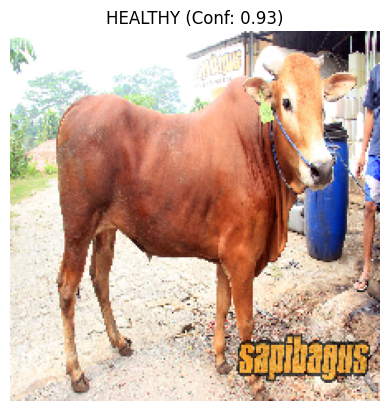


💡 Kesimpulan Prediksi:
    - Terdeteksi sebagai: HEALTHY
    - Tingkat keyakinan: 93.24%

📄 Output JSON:
{
  "predictions": [
    {
      "class": "Healthy",
      "class_id": 1,
      "confidence": 0.9324120283126831
    }
  ]
}


In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import json
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

def prediksi_mobilenet(image_path, model_path, class_json_path):
    # 1. Memuat model dan file JSON berisi nama kelas
    try:
        model = load_model(model_path)
        with open(class_json_path, 'r') as f:
            # Karena JSON key selalu string (misal: "0", "1"), kita biarkan aslinya
            class_names = json.load(f)
    except Exception as e:
        print("❌ ERROR: Gagal memuat model atau file JSON kelas.")
        print(e)
        return {"predictions": []}

    print(f"\n📦 Memulai prediksi pada gambar: {image_path}")

    # 2. Memuat dan memproses gambar uji (harus disamakan dengan saat training: 224x224 dan rescale 1/255)
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)


    # 3. Melakukan inferensi / tebakan model
    predictions = model.predict(img_array, verbose=0)
    print("\nProbabilitas setiap kelas:")
    for idx, prob in enumerate(predictions[0]):
        print(f"{class_names[str(idx)]}: {prob:.4f}")


    # 4. Mencari kelas dengan probabilitas / confidence tertinggi
    predicted_class_idx = np.argmax(predictions[0])
    confidence = float(predictions[0][predicted_class_idx])

    # Mengambil nama label berdasarkan index (mengubah index ke string untuk mencocokkan key JSON)
    predicted_label = class_names[str(predicted_class_idx)]

    # 5. Menampilkan gambar dan hasil prediksi
    print("\n✅ Hasil Visual Klasifikasi:")
    plt.imshow(img)
    plt.title(f"{predicted_label.upper()} (Conf: {confidence:.2f})")
    plt.axis('off')
    plt.show()

    # 6. Menyusun Output dalam format JSON
    json_output = {
        "predictions": [
            {
                "class": predicted_label,
                "class_id": int(predicted_class_idx),
                "confidence": confidence
            }
        ]
    }

    print(f"\n💡 Kesimpulan Prediksi:")
    print(f"    - Terdeteksi sebagai: {predicted_label.upper()}")
    print(f"    - Tingkat keyakinan: {confidence * 100:.2f}%")

    print("\n📄 Output JSON:")
    print(json.dumps(json_output, indent=2))

    return json_output

# ==========================================
# KONFIGURASI PENGUJIAN (UBAH BAGIAN INI)
# ==========================================
MODEL_PATH = '/content/tes1_best_v3.keras'
CLASS_JSON = '/content/class_names.json'

# Ganti dengan path/nama file gambar yang baru Anda upload ke Colab
GAMBAR_UJI = '/content/sapii.jpg'

# Jalankan fungsi prediksi
hasil = prediksi_mobilenet(GAMBAR_UJI, MODEL_PATH, CLASS_JSON)

Confusion Matrix

Found 92 images belonging to 3 classes.
⏳ Predicting...
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step
Contoh Probabilitas (FMD, LSD, Healthy):
[[9.9999988e-01 1.1101277e-11 8.3487826e-08]
 [1.0000000e+00 3.9146362e-09 2.8711591e-08]
 [9.9999237e-01 7.5304088e-06 1.7423207e-07]
 [9.9999893e-01 1.0700647e-06 2.0884280e-10]
 [1.0000000e+00 4.9616133e-10 9.1495245e-10]]
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


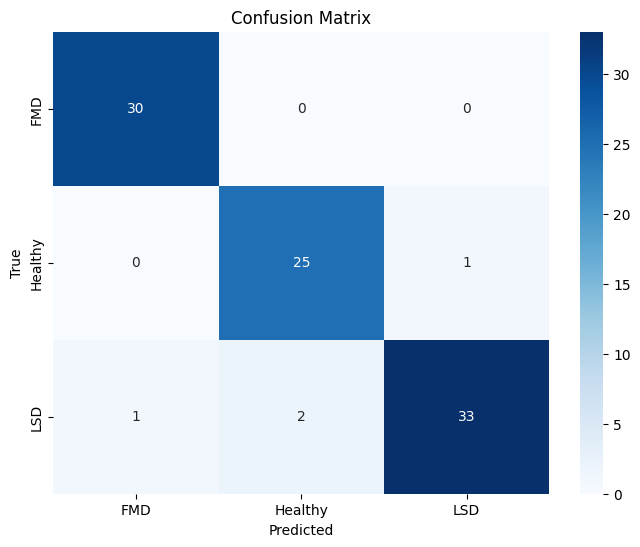


Classification Report:
              precision    recall  f1-score   support

         FMD       0.97      1.00      0.98        30
     Healthy       0.93      0.96      0.94        26
         LSD       0.97      0.92      0.94        36

    accuracy                           0.96        92
   macro avg       0.95      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# 1. Load model
MODEL_PATH = '/content/tes1_best_v3.keras'
model = load_model(MODEL_PATH)

# 2. Definisikan direktori validasi/test
VALID_DIR = '/content/FMD-and-LSD-cattle-disease-2/valid'  # <-- sesuaikan

# 3. BUAT ulang generator (WAJIB, walau sudah training sebelumnya)
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_generator_cm = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 4. Ambil label asli
y_true = valid_generator_cm.classes
nama_kelas = list(valid_generator_cm.class_indices.keys())

# 5. Prediksi
# Tambahkan ini di poin 5 kode Anda
print("⏳ Predicting...")
y_pred_probs = model.predict(valid_generator_cm)

# Lihat 5 prediksi pertama
print("Contoh Probabilitas (FMD, LSD, Healthy):")
print(y_pred_probs[:5])

y_pred = np.argmax(y_pred_probs, axis=1)

#y_pred_probs = model.predict(valid_generator_cm)
#y_pred = np.argmax(y_pred_probs, axis=1)

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=nama_kelas))

In [ ]:
print(model.names)

In [ ]:
print(model.task)

detect


**Reformat/Convert to Tflite**

In [16]:
import tensorflow as tf

model = tf.keras.models.load_model("tes1_best_v3.keras")

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Default = float32
tflite_model_fp32 = converter.convert()

with open("model_fp32.tflite", "wb") as f:
    f.write(tflite_model_fp32)

print("Sukses membuat model_fp32.tflite")

Saved artifact at '/tmp/tmp64x42gys'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139296500470160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500465744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500470352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500468816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500470928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500467088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500466320

In [18]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimasi
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Float16 quantization
converter.target_spec.supported_types = [tf.float16]

tflite_model_fp16 = converter.convert()

with open("model_fp16.tflite", "wb") as f:
    f.write(tflite_model_fp16)

print("Sukses membuat model_fp16.tflite")

Saved artifact at '/tmp/tmpogyxdpwk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139296500470160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500465744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500470352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500468816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500469008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500470928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500467088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139296500466320

Cek Input/Output Shape Model

In [ ]:
# Install TFLite tools (jika belum)
!pip install tensorflow

In [ ]:
# Cek model info
import tensorflow as tf;
interpreter = tf.lite.Interpreter(model_path='/content/model.tflite');
interpreter.allocate_tensors();
print('Input:', interpreter.get_input_details());
print('Output:', interpreter.get_output_details())

Input: [{'name': 'images', 'index': 0, 'shape': array([  1, 640, 640,   3], dtype=int32), 'shape_signature': array([  1, 640, 640,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'Identity', 'index': 611, 'shape': array([   1,    8, 8400], dtype=int32), 'shape_signature': array([   1,    8, 8400], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
